In [1]:
# Load a COLMAP reconstruction using pycolmap
import pycolmap
import pathlib

# Define the path to the reconstruction model directory
model_path = pathlib.Path('./output/0')  # Change to the correct model directory if needed

# Load the reconstruction
reconstruction = pycolmap.Reconstruction(model_path)

# Print basic info about the reconstruction
print(f"Number of registered images: {len(reconstruction.images)}")
print(f"Number of 3D points: {len(reconstruction.points3D)}")

Number of registered images: 37
Number of 3D points: 4029


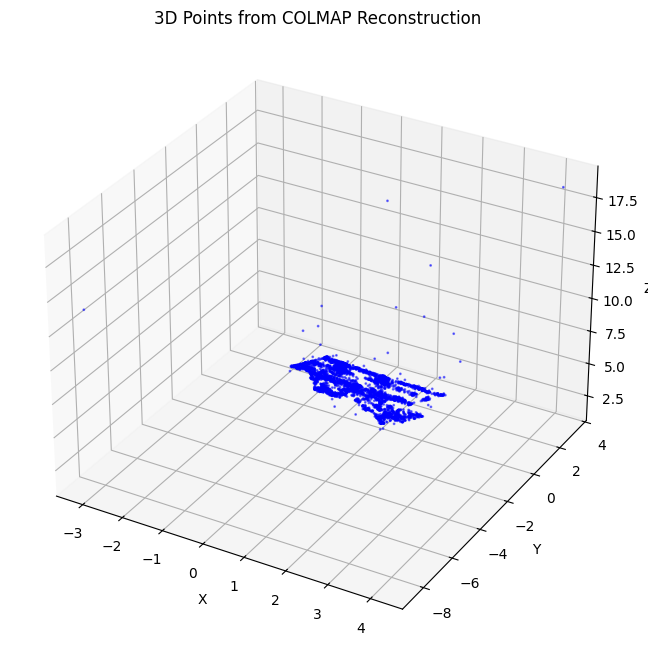

In [2]:
# Plot the 3D points from the reconstruction
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Extract 3D point coordinates
points3D = np.array([p.xyz for p in reconstruction.points3D.values()])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points3D[:, 0], points3D[:, 1], points3D[:, 2], s=1, c='b', alpha=0.5)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Points from COLMAP Reconstruction')
plt.show()

In [3]:
import plotly.express as px
import numpy as np

# Generate sample data
t = np.linspace(0, 2 * np.pi, 100)
x = np.sin(t)
y = np.cos(t)
z = t

# Create a 3D scatter plot
fig = px.scatter_3d(x=x, y=y, z=z)

# Show the plot
fig.show()

In [4]:
# Interactive 3D scatter plot of reconstruction points using Plotly
import plotly.graph_objs as go

# Extract 3D point coordinates (if not already extracted)
points3D = np.array([p.xyz for p in reconstruction.points3D.values()])

fig = go.Figure(data=[go.Scatter3d(
    x=points3D[:, 0],
    y=points3D[:, 1],
    z=points3D[:, 2],
    mode='markers',
    marker=dict(
        size=2,
        color=points3D[:, 2],  # Color by Z value for effect
        colorscale='Viridis',
        opacity=0.7
    )
)])

fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    title='Interactive 3D Points from COLMAP Reconstruction',
    width=900,
    height=700
)
fig.show()